In [2]:
## conda activate gift_spatial

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd

matplotlib.rcParams['pdf.fonttype'] = 42

import sys
sys.path.append('../../figure_CL_proof_of_concept/code/')

from spatial_utils import read_dual_probe_data, read_gapfill_data, read_genotype_annotations, plot_wt_alt_alleles_spatial

import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


/data1/lareauc/users/blattms/miniconda3/envs/gift_spatial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_path = f"{large_data_dir}gf_CL_VisiumHD/"
# Load data:
gapfill_sdata = read_gapfill_data(gf_adata_path = f"{data_path}GapFill_CellLineMix_Visium_GF.h5ad", WTA_dir = f"{data_path}GapFill_WTA.zarr")
annotated_genotypes, celltype_genotypes, wt_alleles, alt_alleles = read_genotype_annotations()

/home/blattms1/projects/gapfill/gift_paper_reproducibility/1_figure_CL_proof_of_concept/code/spatial_utils.py:194: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  gapfill_wta = read_zarr(WTA_dir)


Info: if genotyping takes too long, consider setting cores > 1.


Genotyping : 100%|██████████| 159/159 [00:14<00:00, 10.97it/s, Probe ZNF609]                             
/data1/lareauc/users/blattms/miniconda3/envs/gift_spatial/lib/python3.12/site-packages/giftwrap/analysis/spatial.py:280: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  gf_table.uns[sd.models.TableModel.ATTRS_KEY] = wta_table.uns[sd.models.TableModel.ATTRS_KEY].copy()


Info: Calling genotypes for the binned data using the previous arguments:
flavor: basic
threshold: 0.5
cores: 1
Info: if genotyping takes too long, consider setting cores > 1.


Genotyping : 100%|██████████| 159/159 [00:05<00:00, 27.28it/s, Probe ZNF609]                             
/data1/lareauc/users/blattms/miniconda3/envs/gift_spatial/lib/python3.12/site-packages/giftwrap/analysis/spatial.py:280: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  gf_table.uns[sd.models.TableModel.ATTRS_KEY] = wta_table.uns[sd.models.TableModel.ATTRS_KEY].copy()


Info: Calling genotypes for the binned data using the previous arguments:
flavor: basic
threshold: 0.5
cores: 1
Info: if genotyping takes too long, consider setting cores > 1.


Genotyping : 100%|██████████| 159/159 [00:02<00:00, 60.30it/s, Probe ZNF609]                             
/data1/lareauc/users/blattms/miniconda3/envs/gift_spatial/lib/python3.12/site-packages/giftwrap/analysis/spatial.py:280: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  gf_table.uns[sd.models.TableModel.ATTRS_KEY] = wta_table.uns[sd.models.TableModel.ATTRS_KEY].copy()


Total Spots with WT only: 1109
Total Spots with ALT only: 4838
Total Spots with HET: 12


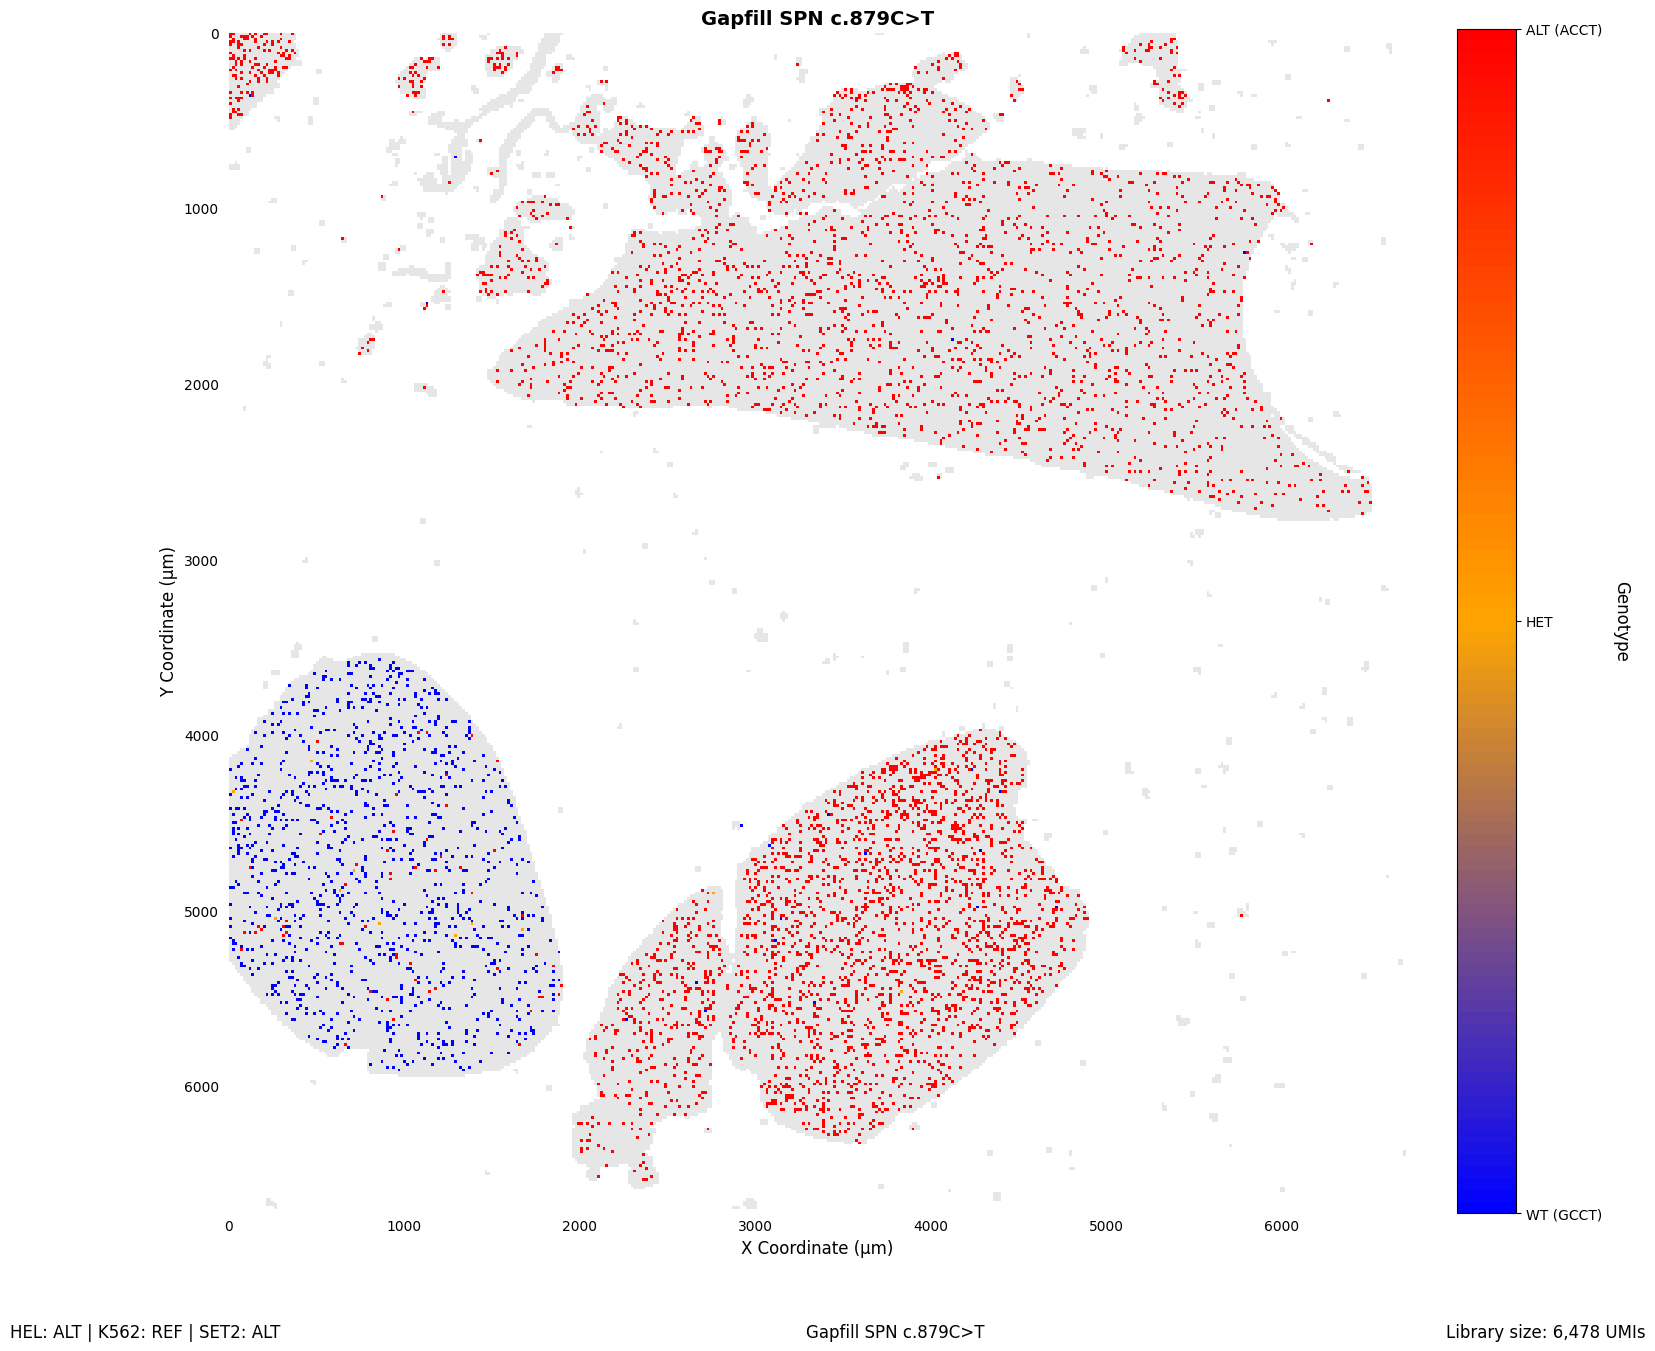

Total Spots with WT only: 927
Total Spots with ALT only: 4164
Total Spots with HET: 32


<Figure size 640x480 with 0 Axes>

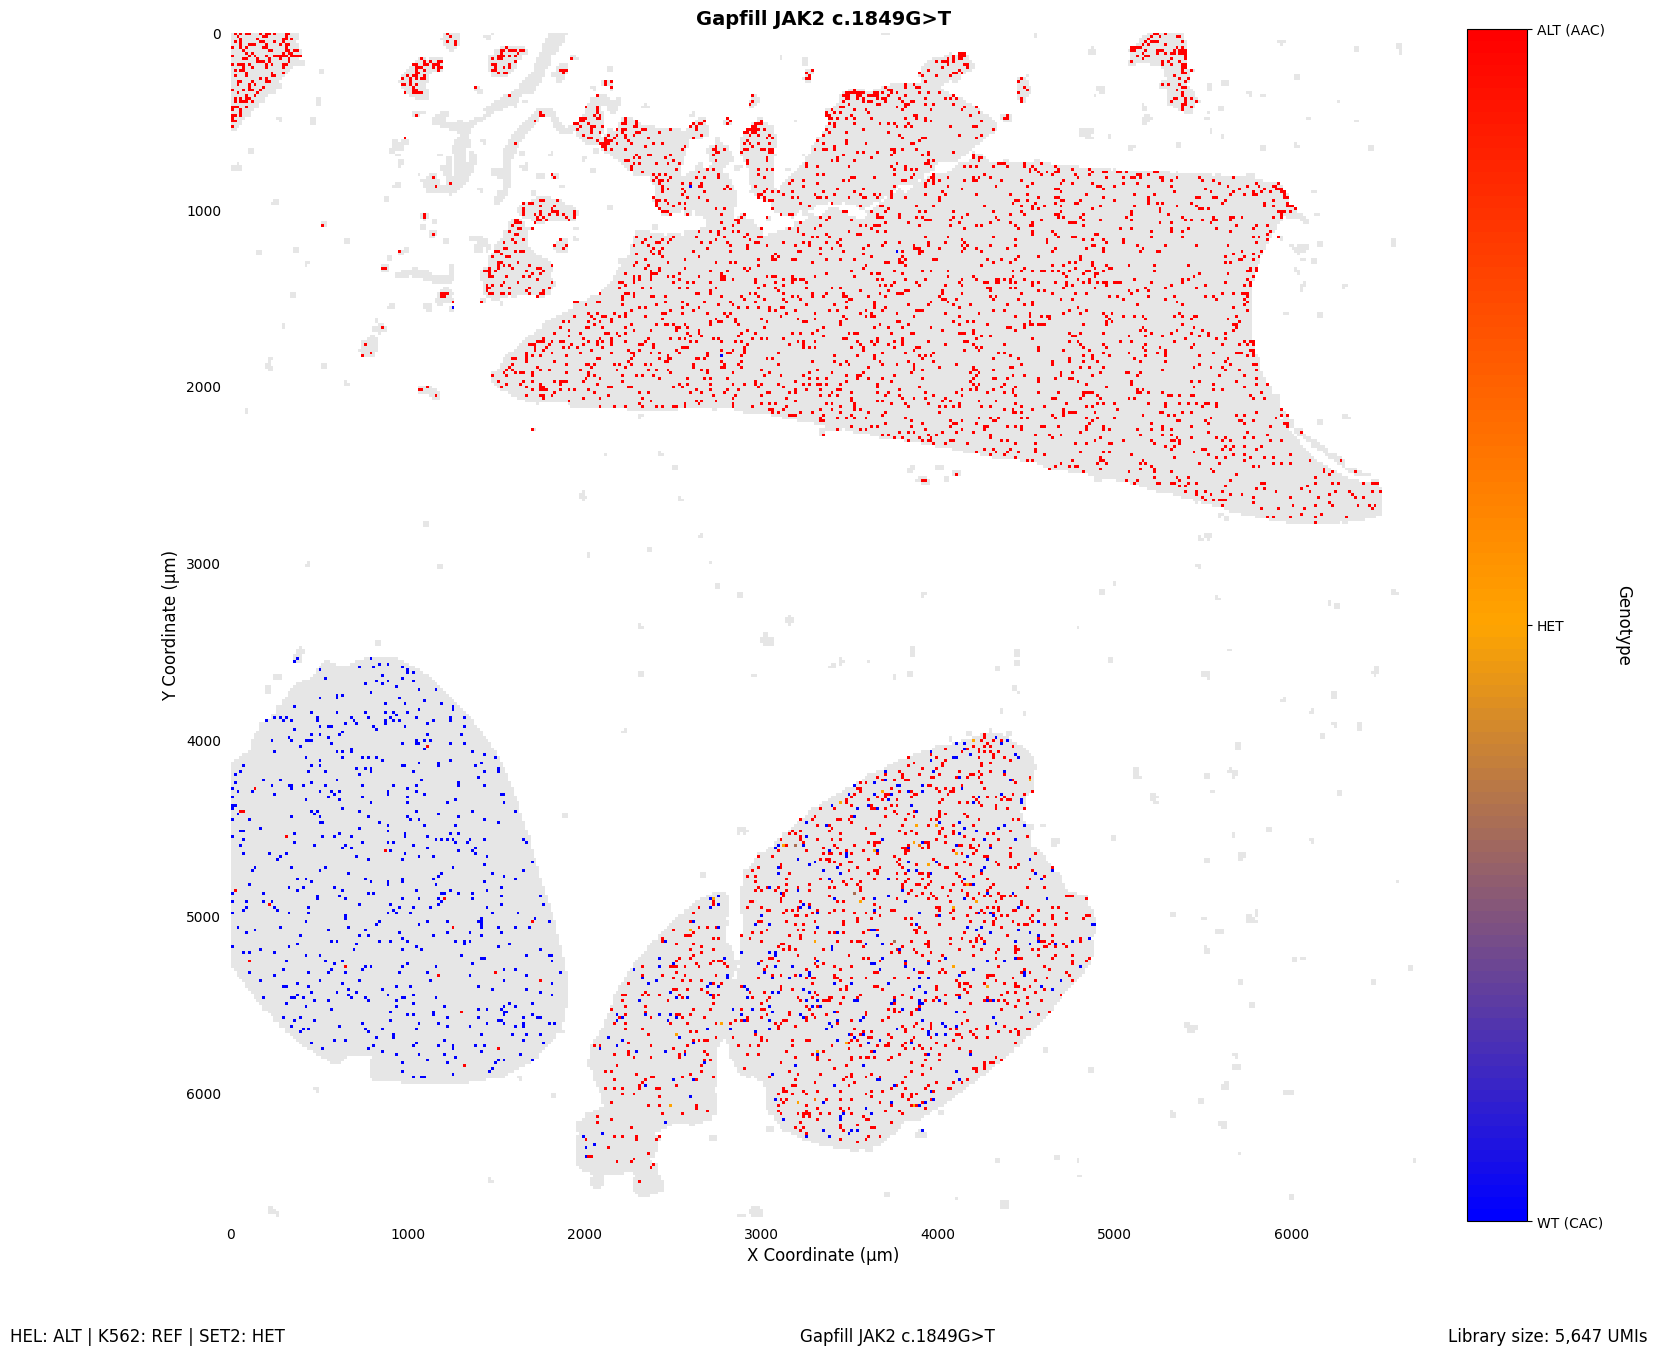

Total Spots with WT only: 2214
Total Spots with ALT only: 1812
Total Spots with HET: 2


<Figure size 640x480 with 0 Axes>

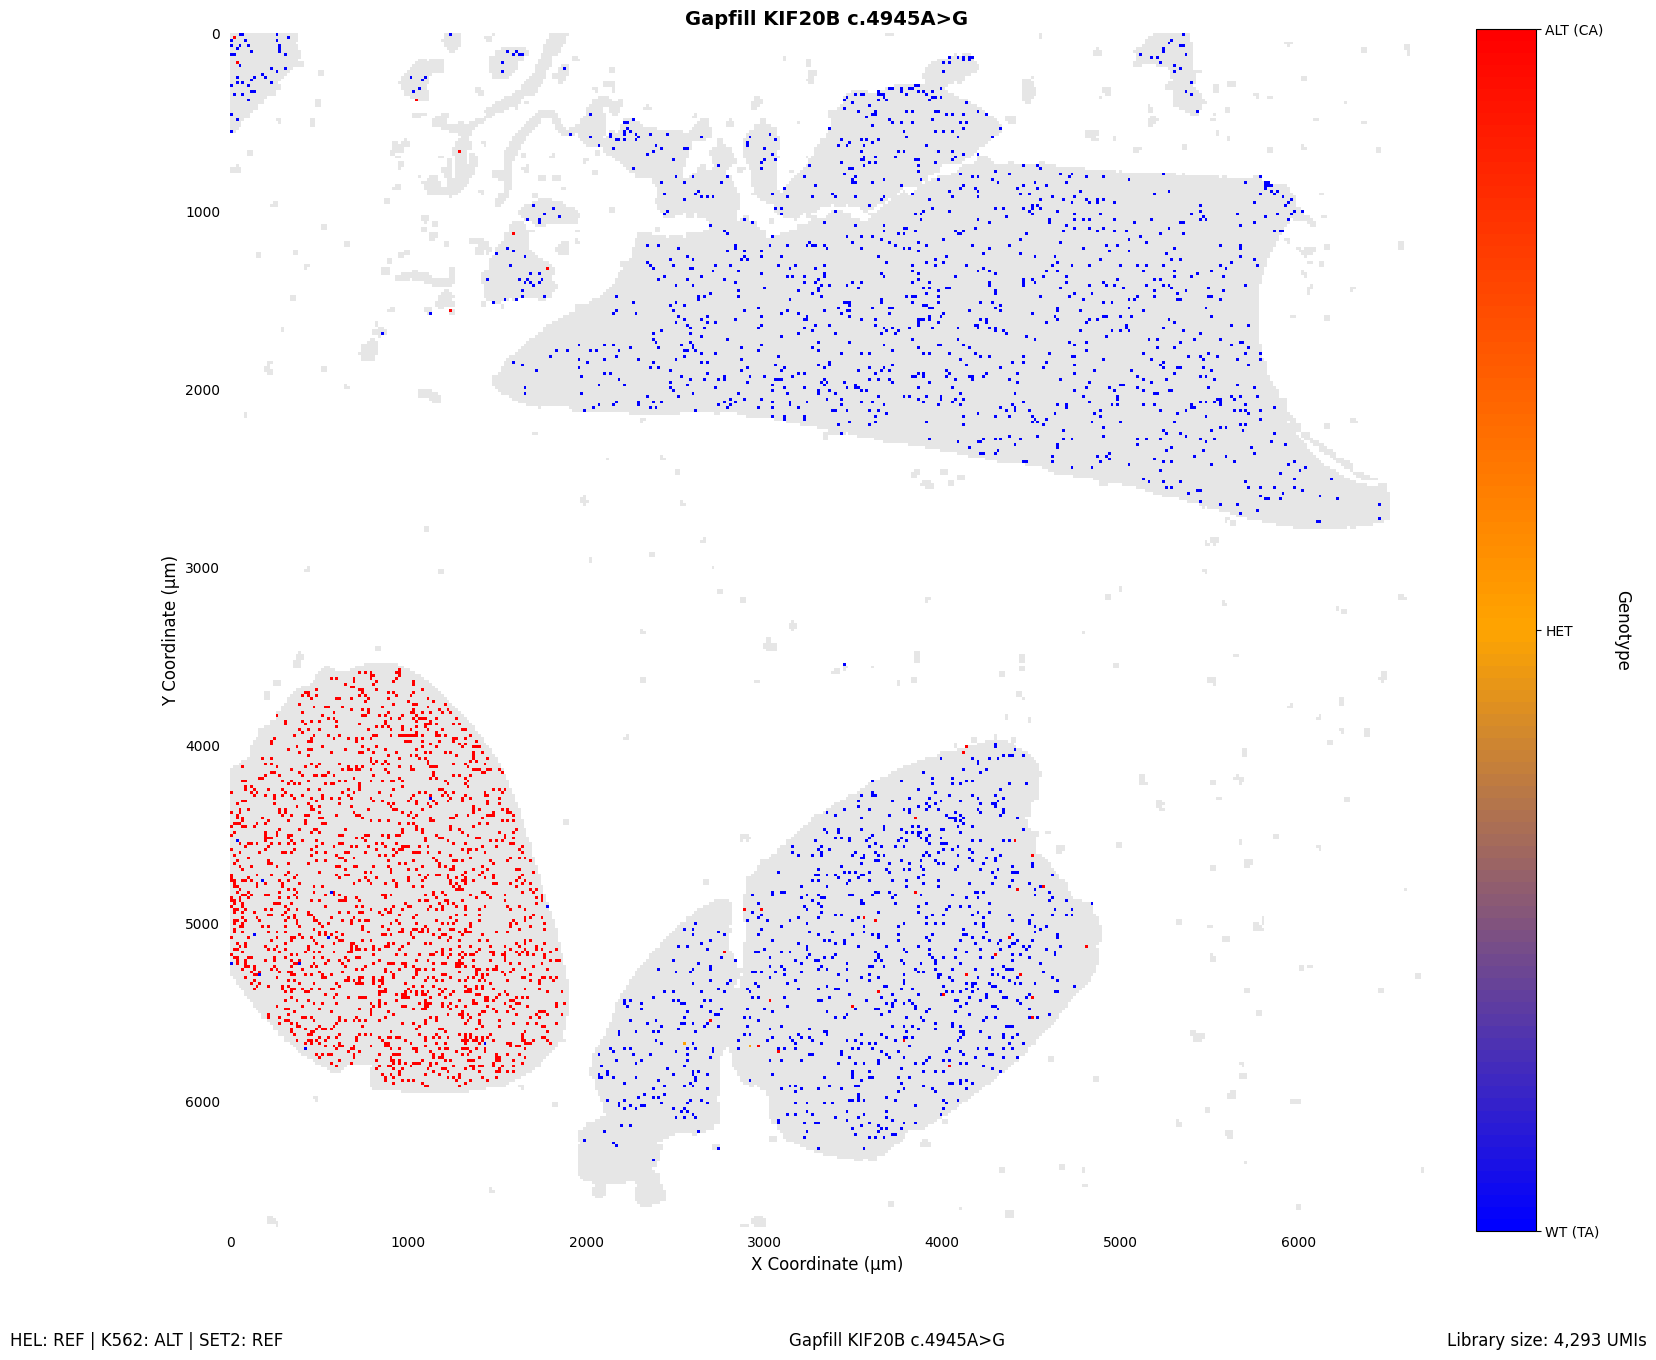

Total Spots with WT only: 2447
Total Spots with ALT only: 1493
Total Spots with HET: 20


<Figure size 640x480 with 0 Axes>

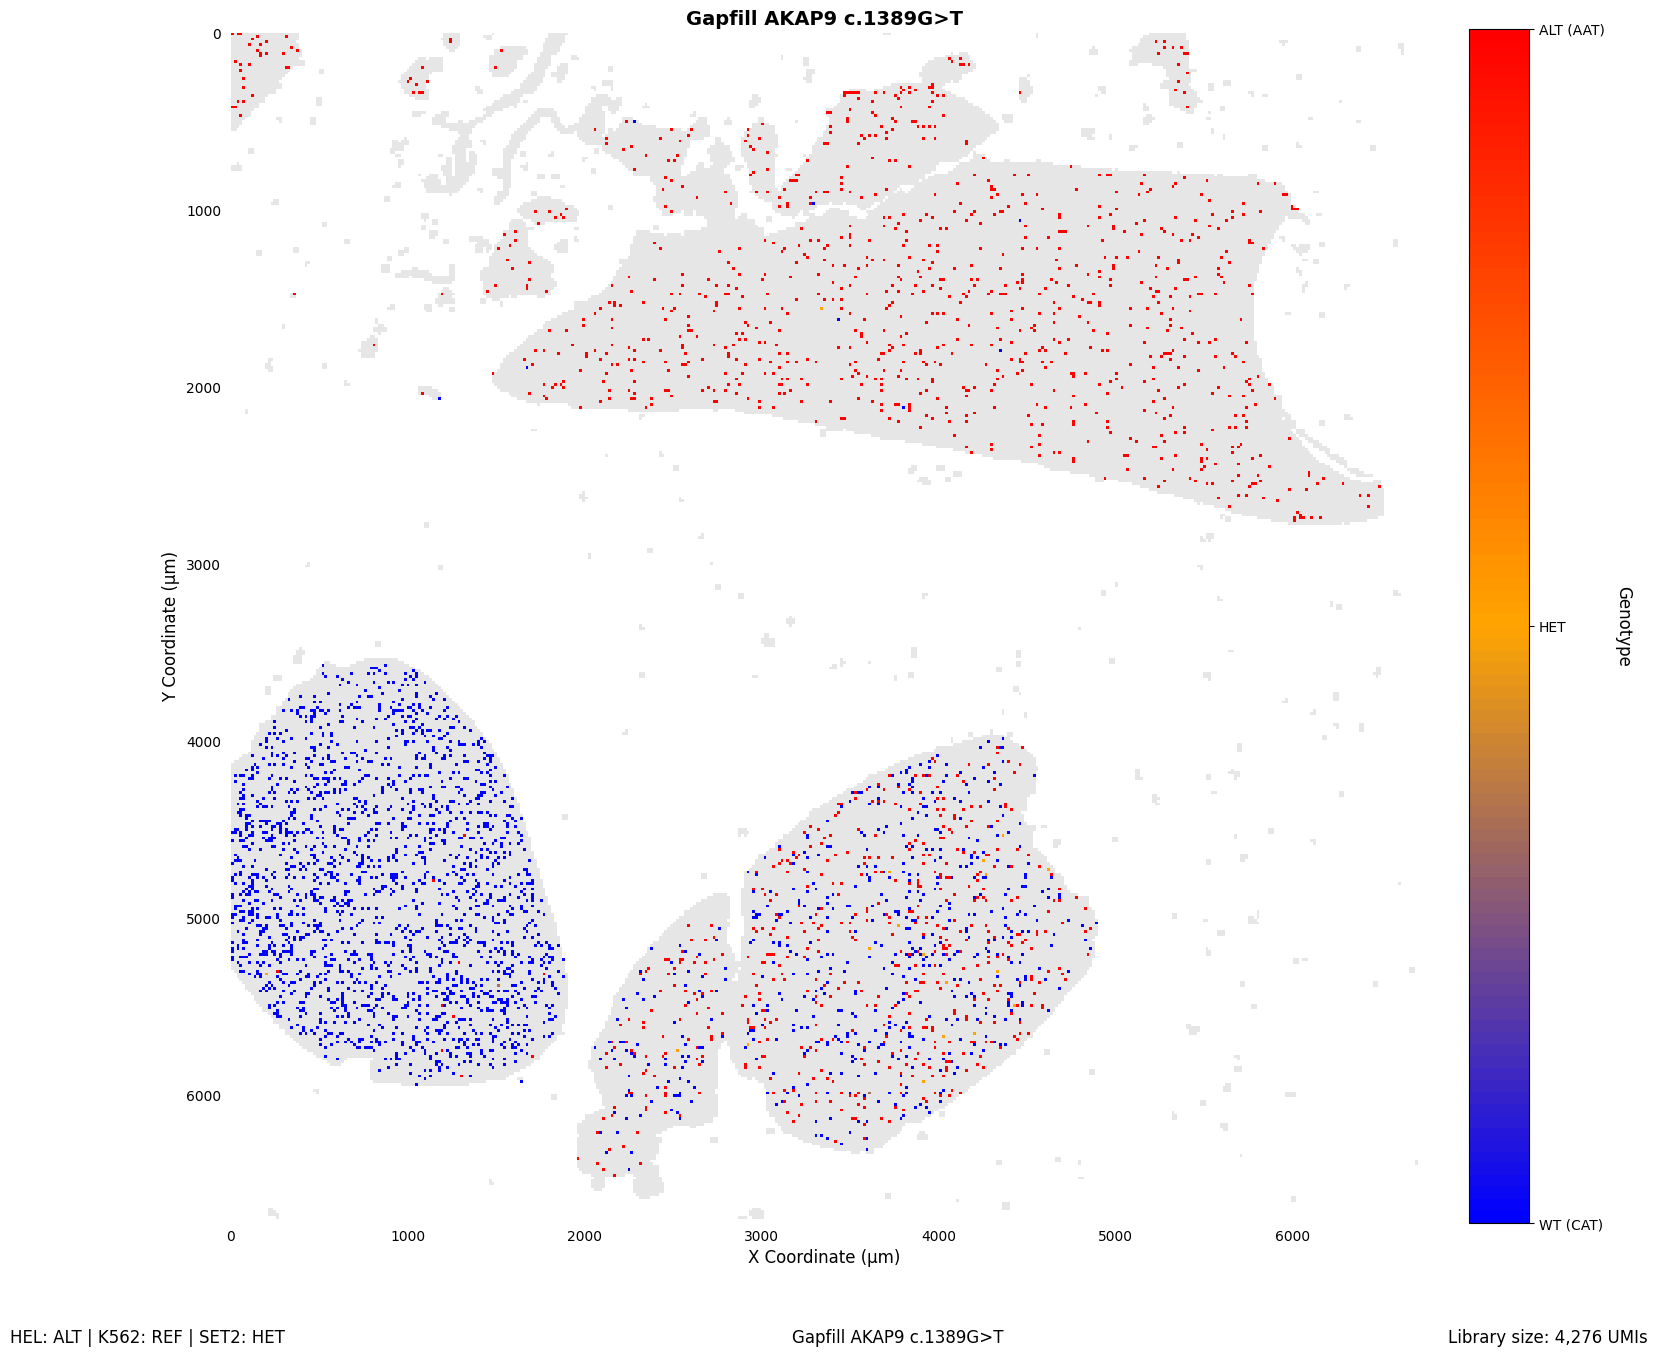

Total Spots with WT only: 3212
Total Spots with ALT only: 2264
Total Spots with HET: 40


<Figure size 640x480 with 0 Axes>

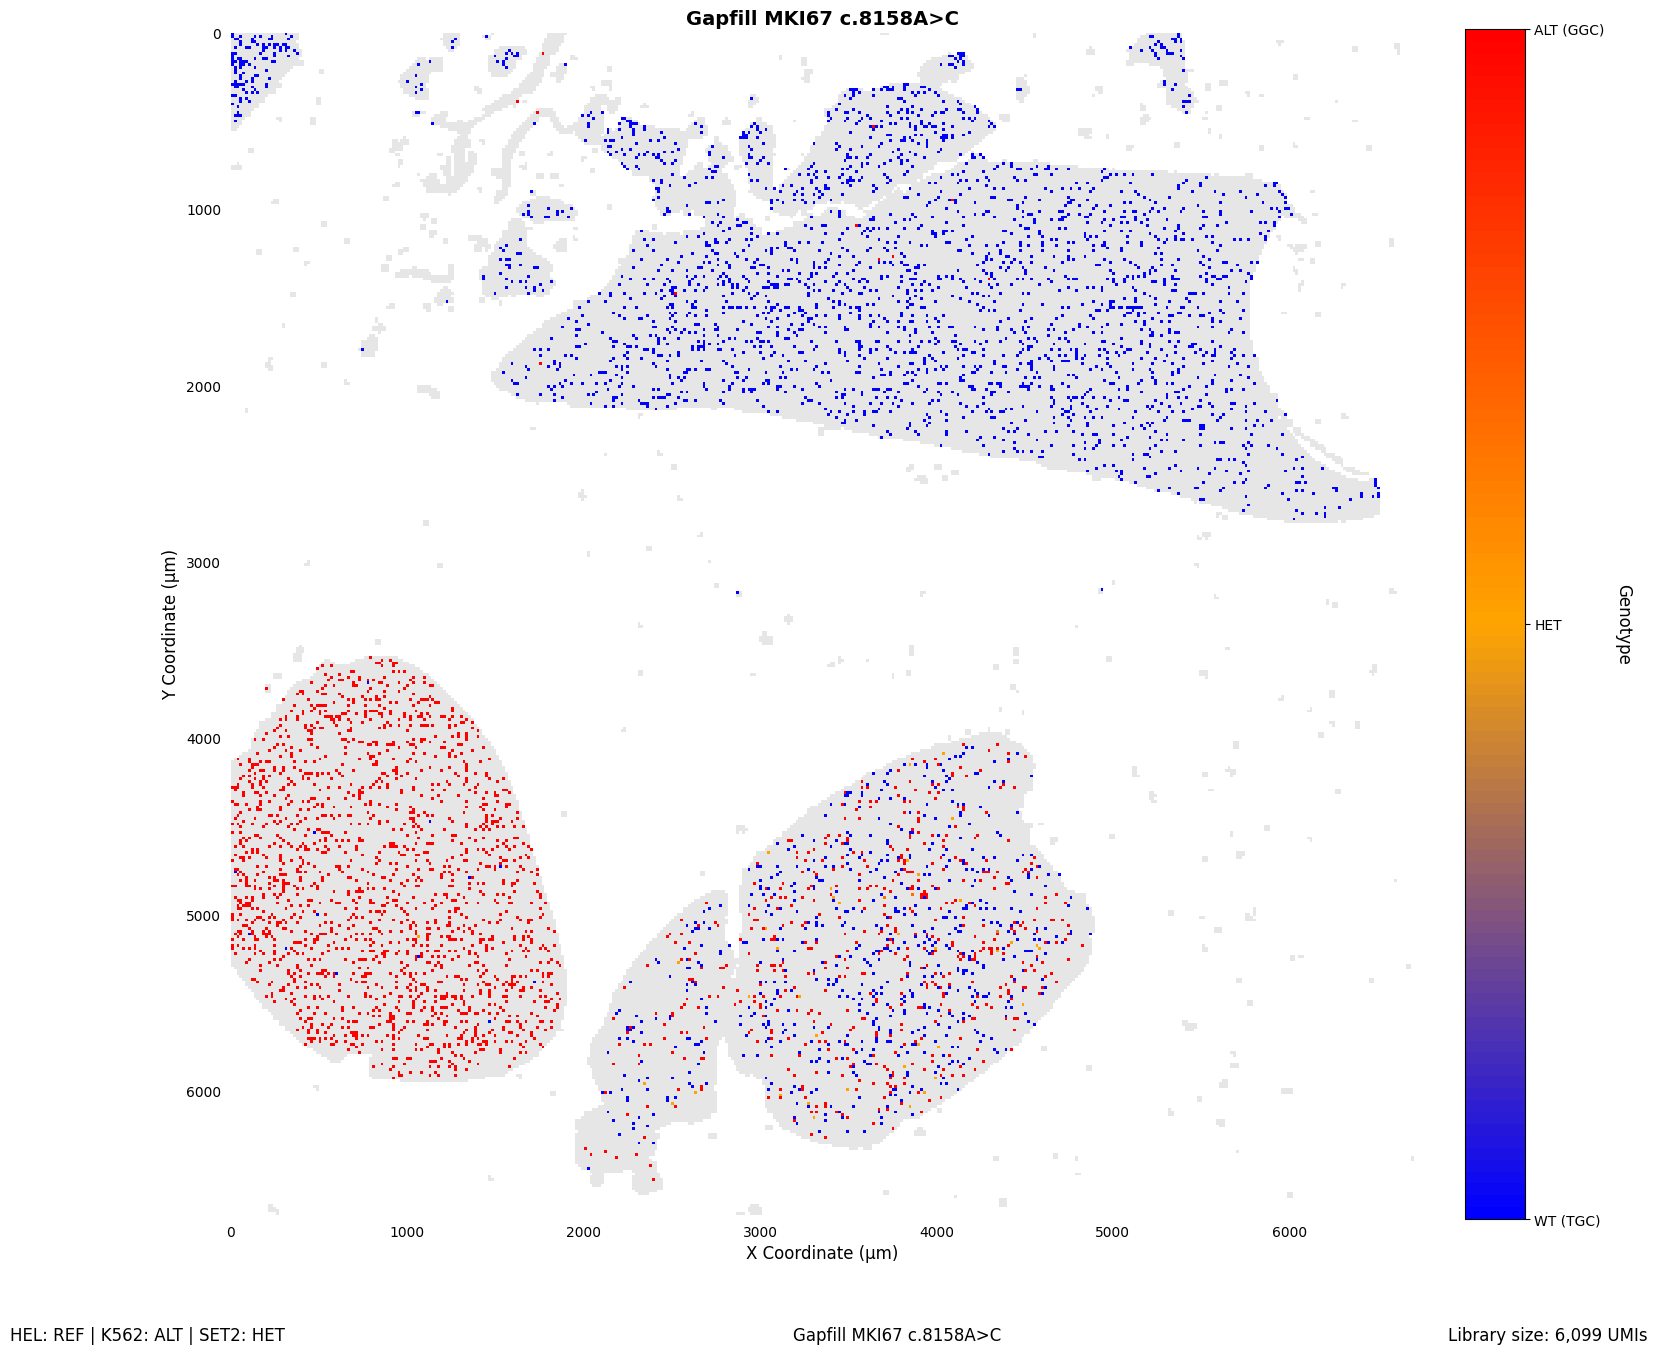

Total Spots with WT only: 6049
Total Spots with ALT only: 1853
Total Spots with HET: 75


<Figure size 640x480 with 0 Axes>

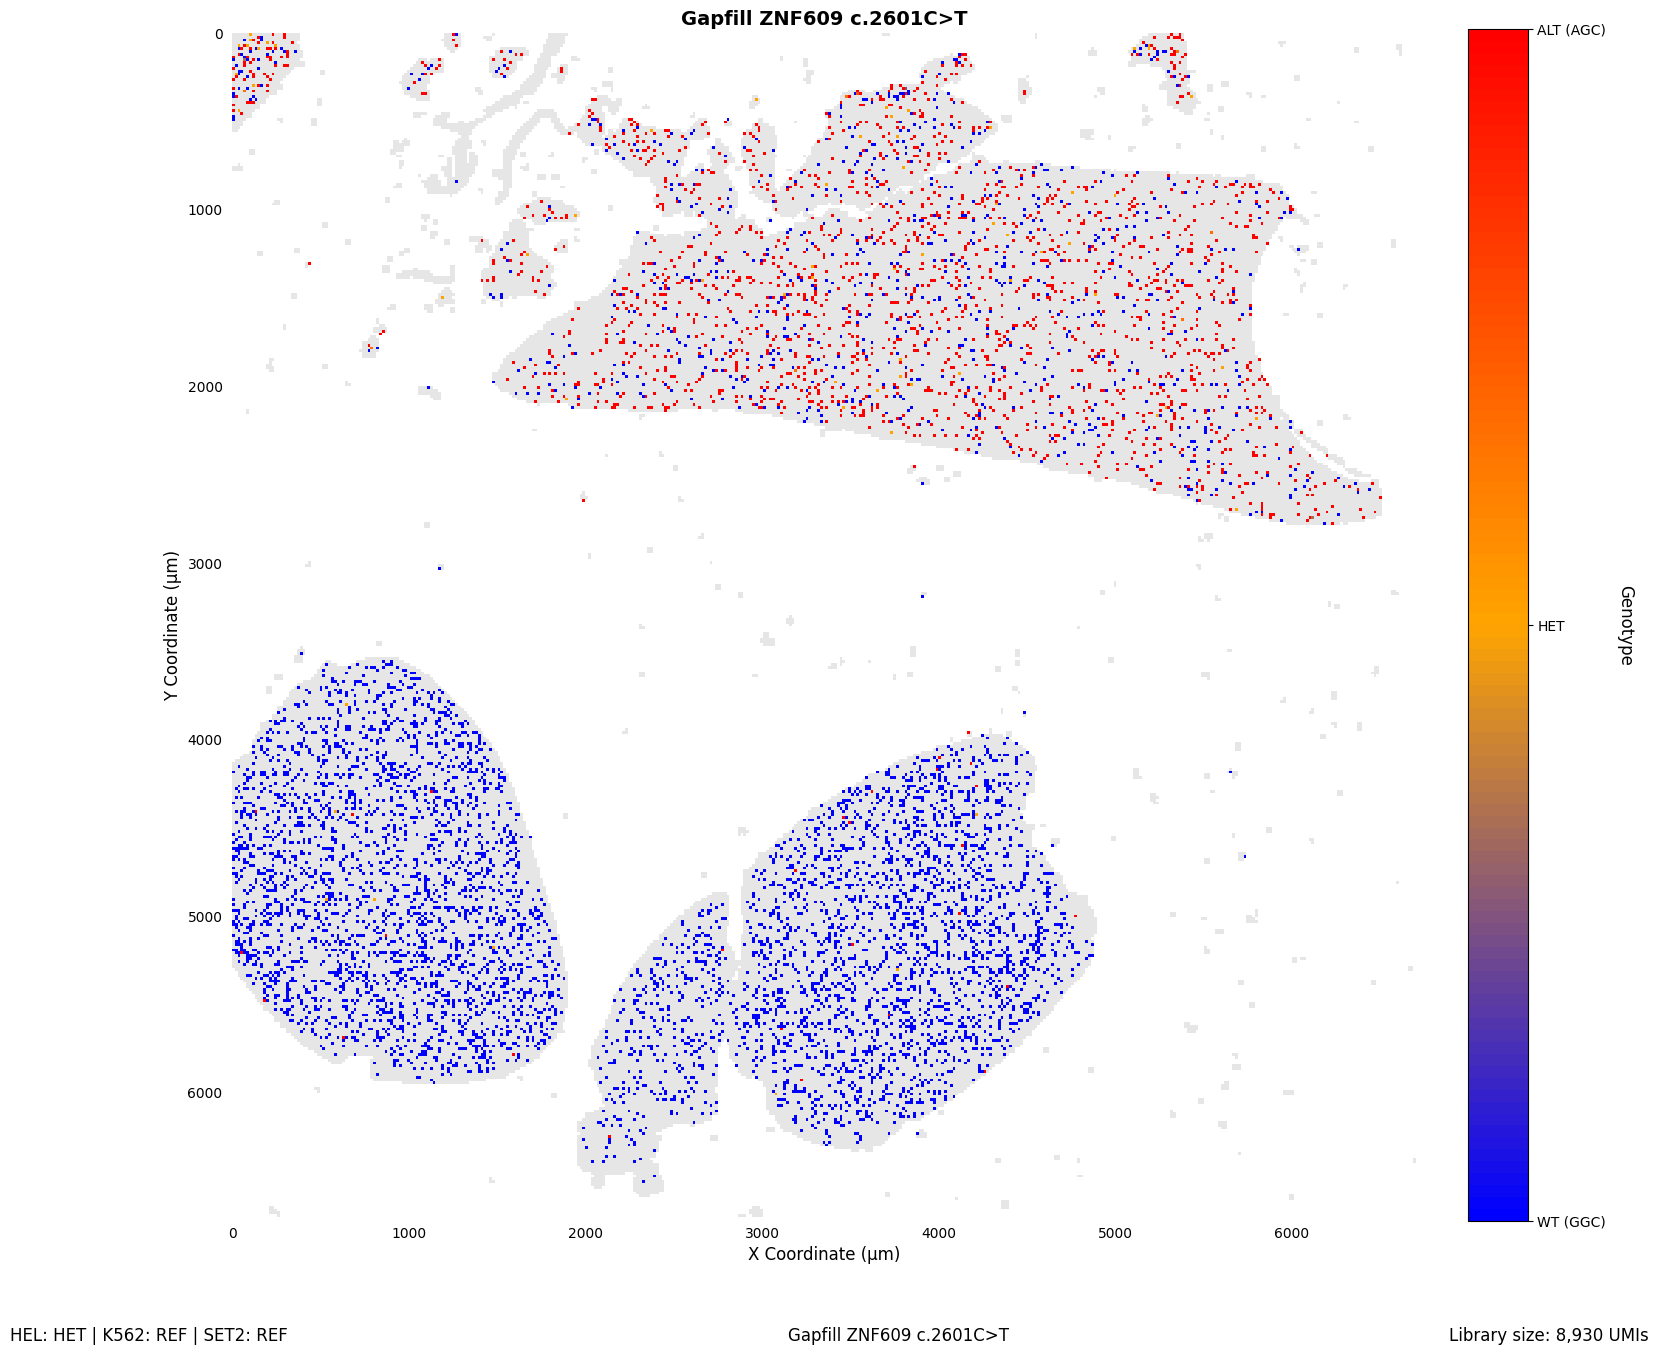

<Figure size 640x480 with 0 Axes>

In [4]:
def _genotype_label(gapfills, probe_name):
    """Map gapfill sequences to REF/HET/ALT label."""
    wt = wt_alleles.get(probe_name)
    alt = alt_alleles.get(probe_name)
    has_ref = any(g == wt for g in gapfills if pd.notna(g))
    has_alt = any(g == alt for g in gapfills if pd.notna(g))
    if has_ref and has_alt:
        return "HET"
    elif has_alt:
        return "ALT"
    else:
        return "REF"

def _get_library_size(gf_probe):
    """Get total library size (UMI count) for a probe across all bins."""
    gf_table = gapfill_sdata.tables['gf_square_016um']
    probe_mask = (gf_table.var.probe == gf_probe).values
    if probe_mask.any():
        return int(gf_table.X[:, probe_mask].sum())
    return 0

def spatial_plot(gf_probe):
    name = gf_probe
    if "|" in gf_probe:
        name = " ".join(gf_probe.split("|")[1:])
    caption = f"Gapfill {name}"  # Caption to annotate the plot
    fig, axes, summary = plot_wt_alt_alleles_spatial(
        gapfill_sdata,
        gf_probe,
        wt_alleles,
        alt_alleles,
        include_he=False,
        resolution=16,
        title=f"Gapfill {name}"
    )
    fig.text(0.5, 0.02, caption, ha="center", va="bottom", fontsize=12)
    # Plot the cell line names mapped to REF/ALT/HET caption
    fig.text(0., 0.02, " | ".join([
        f"{cell_line}: {_genotype_label(genotypes[name], name)}" for cell_line, genotypes in celltype_genotypes.items() if name in genotypes
    ]), ha="center", va="bottom", fontsize=12)
    # Library size caption
    lib_size = _get_library_size(gf_probe)
    fig.text(1.0, 0.02, f"Library size: {lib_size:,} UMIs", ha="right", va="bottom", fontsize=12)

    plt.tight_layout()
    plt.savefig(f'../plots/visium_dual_vs_gapfill_{name.replace(" ", "_").replace("c.", "")}.pdf', bbox_inches='tight')
    plt.show()
    plt.clf()

for gf_probe in [
    'SET2_homozygous|SPN|c.879C>T',
    'JAK2 c.1849G>T',
    'K562_homozygous|KIF20B|c.4945A>G',
    'MM1S_homozygous|AKAP9|c.1389G>T',
    'K562_homozygous|MKI67|c.8158A>C',
    'MM1S_heterozygous|ZNF609|c.2601C>T'

]:
    spatial_plot(gf_probe)